# 1 - Twitter Sentiment Analysis - NLP

<img src='https://editor.analyticsvidhya.com/uploads/15549Screenshot%20from%202022-06-02%2012-57-35.png'>

Bu çalışmada Twitter paylaşımlarının duygu durumunu tahmin eden bir NLP modeli geliştireceğim.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Metin ön işleme
5. TF-IDF ile sayısallaştırma
6. Classification modelleri kurma
7. En iyi modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen Twitter sentiment datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Twitter Tweets Sentiment Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'Tweets.csv', 'drive', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [6]:
file_path = '/content/Tweets.csv'

df = pd.read_csv(file_path)
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [7]:
df.shape

(27481, 4)

In [8]:
df.columns.tolist()

['textID', 'text', 'selected_text', 'sentiment']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


## 3. Veri Temizleme

In [10]:
# Bu bölümde boş verileri temizleyip sadece gerekli sütunlarla çalışacağım.

In [11]:
df = df[['text', 'sentiment']].dropna().copy()
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [12]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


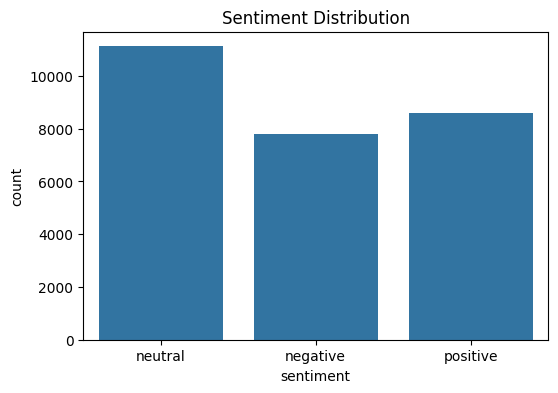

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

## 4. Metin Ön İşleme

In [14]:
# Bu bölümde tweet metinlerini küçük harfe çevirip link, noktalama ve gereksiz karakterleri temizleyeceğim.

In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,"I`d have responded, if I were going",id have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego
2,my boss is bullying me...,my boss is bullying me
3,what interview! leave me alone,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldnt they put them on the relea...


## 5. TF-IDF ile Sayısallaştırma

In [16]:
# Bu bölümde temizlenmiş metinleri TF-IDF ile sayısal özelliklere dönüştüreceğim.

In [17]:
x = df['clean_text']
y = df['sentiment']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

x_train_tfidf.shape, x_test_tfidf.shape

((21984, 5000), (5496, 5000))

## 6. Classification Modelleri Kurma

In [18]:
# Bu bölümde birkaç farklı classification modeli kurup sonuçları karşılaştıracağım.

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(x_train_tfidf, y_train)
    y_pred = model.predict(x_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append([name, accuracy, f1])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,F1
0,Logistic Regression,0.683770,0.684649
2,Random Forest,0.674127,0.673410
1,Multinomial Naive Bayes,0.632096,0.628640


## 7. En İyi Modeli Değerlendirme

In [20]:
# Bu bölümde en başarılı modeli seçip detaylı sonuçlarını inceleyeceğim.

In [21]:
best_model_name = results_df.sort_values(by='F1', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test_tfidf)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test, best_pred))
print('F1 Score:', f1_score(y_test, best_pred, average='weighted'))
print(classification_report(y_test, best_pred))

Best Model: Logistic Regression
Accuracy: 0.6837700145560408
F1 Score: 0.6846489155453253
              precision    recall  f1-score   support

    negative       0.72      0.61      0.66      1556
     neutral       0.61      0.74      0.67      2223
    positive       0.78      0.68      0.73      1717

    accuracy                           0.68      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.70      0.68      0.68      5496



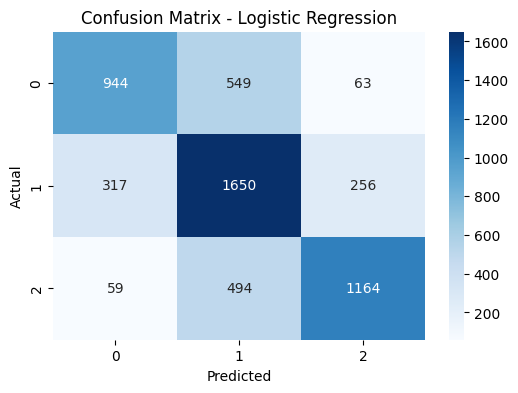

In [22]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [23]:
# Bu bölümde örnek bir tweet için duygu tahmini yapacağım.

In [24]:
sample_text = x_test.iloc[0]
sample_vector = vectorizer.transform([sample_text])
sample_prediction = best_model.predict(sample_vector)[0]

print('Tweet:', sample_text)
print('Tahmin edilen sentiment:', sample_prediction)
print('Gerçek sentiment:', y_test.iloc[0])

Tweet: reading and taking notes but undertanding none of it help
Tahmin edilen sentiment: negative
Gerçek sentiment: negative


## 9. Sonuç

Bu projede tweet metinlerinin duygu durumunu tahmin etmek için NLP tabanlı bir classification modeli kullanıldı. Elde edilen sonuçlara göre en başarılı model 0.6838 accuracy ve 0.6846 F1 score değeri ile Logistic Regression oldu.
